In [4]:
import pandas as pd
import numpy as np
!pip install country_converter > /dev/null
import country_converter as coco
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.figure_factory as ff
import plotly.graph_objects as go
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")
import nltk

%matplotlib inline

In [5]:
df = pd.read_csv("data_science_salaries.csv")
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [6]:
df.isnull().sum()

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB


In [9]:
ex_level = df["experience_level"].value_counts()
fig = px.treemap(ex_level, path = [ex_level.index], values = ex_level.values, title = "Experience Level")
fig.show(renderer = "iframe_connected")

In [10]:
top15_job_titles = df["job_title"].value_counts()[:15]
fig = px.bar(y = top15_job_titles.values, x = top15_job_titles.index, text = top15_job_titles.values, title = "Top 15 Job Designations")
fig.update_layout(xaxis_title = "Job Designations", yaxis_title = "Count")
fig.show(renderer = "iframe_connected")

In [11]:
country = coco.convert(names = df["employee_residence"], to = "ISO3")
df["employee_residence"] = country

In [12]:
residence = df["employee_residence"].value_counts()
fig = px.choropleth_map(locations = residence.index, 
                        color = residence.values,
                        color_continuous_scale = px.colors.sequential.Reds,
                        title = "Employee Location On Map")

fig.show(renderer = "iframe_connected")

In [14]:
top_10_emp_locations = residence[:10]
fig = px.bar(y = top_10_emp_locations.values, x = top_10_emp_locations.index, 
            color = top_10_emp_locations.index, text = top_10_emp_locations.values,
            title = 'Top 10 Locations of Employees')

fig.update_layout( xaxis_title = "Location of Employees", yaxis_title = "count")
fig.show(renderer='iframe_connected')

In [15]:
country = coco.convert(names=df['company_location'], to="ISO3")
df['company_location'] = country
company_location = df['company_location'].value_counts()
top_10_company_location = company_location[:10]

fig = go.Figure(data = [
    go.Bar(name = 'Employee Residence', 
           x = top_10_emp_locations.index, y = top_10_emp_locations.values,
           text = top_10_emp_locations.values),
    go.Bar(name = 'Company Location', x = top_10_company_location.index, 
           y = top_10_company_location.values, text = top_10_company_location.values)])

fig.update_layout(barmode = 'group', xaxis_tickangle = -45,
                  title='Comparison of Employee Residence and Company Location')

fig.show(renderer='iframe_connected')

In [16]:
group = df["company_size"].value_counts()

fig = px.bar(y = group.values, x = group.index, color = group.index, text = group.values, title = "Distribution of Company Size")
fig.update_layout(xaxis_title= "Company Size", yaxis_title = "count")
fig.show(renderer = "iframe_connected")

In [17]:
work_year = df["work_year"].value_counts()
fig = px.pie(values = work_year.values, names = work_year.index, title = "Work year distribution")
fig.show(renderer = "iframe_connected")

In [18]:
fig = px.box(y = df["salary_in_usd"], title = "Salary in USD")
fig.show(renderer = "iframe_connected")

In [19]:
hist_data = [df["salary_in_usd"]]
group_labels = ["salary_in_usd"]

fig = ff.create_distplot(hist_data, group_labels, show_hist = False)
fig.update_layout(title = "Distribution Plot of Salary in USD")
fig.show(renderer = "iframe_connected")

In [20]:
group = df["employment_type"].value_counts()
emp_type = ["Full-Time", "Part-Time", "Contract", "Freelance"]

fig = px.bar(x = emp_type, y = group.values, color = group.index, text = group.values, title = "Employment Type Distribution")

fig.update_layout(xaxis_title = "Employment Type", yaxis_title = "count")
fig.show(renderer = "iframe_connected")

In [21]:
remote_type = ["Fully Remote", "Partially Remote", "No Remote Work"]

fig = px.bar(x = remote_type, y = df["work_models"].value_counts().values, title = "Remote Ratio Distribution")

fig.update_layout(xaxis_title = "Remote Type", yaxis_title = "count")
fig.show(renderer = "iframe_connected")

In [22]:
remote_year = df.groupby(['work_year','work_models']).size()
ratio_2020 = np.round(remote_year[2020].values/remote_year[2020].values.sum(),2)
ratio_2021 = np.round(remote_year[2021].values/remote_year[2021].values.sum(),2)
ratio_2022 = np.round(remote_year[2022].values/remote_year[2022].values.sum(),2)
ratio_2023 = np.round(remote_year[2023].values/remote_year[2023].values.sum(),2)
ratio_2024 = np.round(remote_year[2024].values/remote_year[2024].values.sum(),2)

fig = go.Figure()
categories = ['No Remote Work', 'Partially Remote', 'Fully Remote']
fig.add_trace(go.Scatterpolar(
            r = ratio_2020, theta = categories, 
            fill = 'toself', name = '2020 remote ratio'))

fig.add_trace(go.Scatterpolar(
            r = ratio_2021, theta = categories,
            fill = 'toself', name = '2021 remote ratio'))

fig.add_trace(go.Scatterpolar(
            r = ratio_2022, theta = categories,
            fill = 'toself', name = '2022 remote ratio'))

fig.add_trace(go.Scatterpolar(
            r = ratio_2023, theta = categories,
            fill = 'toself', name = '2023 remote ratio'))

fig.add_trace(go.Scatterpolar(
            r = ratio_2024, theta = categories,
            fill = 'toself', name = '2024 remote ratio'))

fig.show(renderer='iframe_connected')

In [24]:
exp_job = df.groupby(['experience_level','job_title']).size()

entry_top5 = exp_job['Entry-level'].sort_values(ascending = False)[:5]
executive_top5 = exp_job['Executive-level'].sort_values(ascending = False)[:5]
mid_top5 = exp_job['Mid-level'].sort_values(ascending = False)[:5]
senior_top5 = exp_job['Senior-level'].sort_values(ascending = False)[:5]

exp_type = df.groupby(['experience_level','employment_type']).size()

fig = go.Figure(data=[
    go.Bar(name = 'Entry-level/Junior', x = entry_top5.index, 
           y=entry_top5.values, text = entry_top5.values),
    go.Bar(name = 'Executive-level/Director', x = executive_top5.index,
           y = executive_top5.values, text = executive_top5.values),
    go.Bar(name = 'Mid-level/Intermediate', x = mid_top5.index,
           y = mid_top5.values, text = mid_top5.values ),
    go.Bar(name = 'Senior-level/Expert', x = senior_top5.index,
           y = senior_top5.values, text = senior_top5.values)])

fig.update_layout(xaxis_tickangle = -45, title = 'Experiece Level with top 5 job designations')

fig.show(renderer='iframe_connected')

In [26]:
exp_size = df.groupby(['experience_level','company_size']).size()
fig = go.Figure(data = [
    go.Bar(name = 'Entry-level', x = exp_size['Entry-level'].index,
           y = exp_size['Entry-level'].values, text = exp_size['Entry-level'].values),
    go.Bar(name = 'Executive-level', x = exp_size['Executive-level'].index,
           y = exp_size['Executive-level'].values, text = exp_size['Executive-level'].values),
    go.Bar(name = 'Mid-level', x = exp_size['Mid-level'].index,
           y = exp_size['Mid-level'].values, text = exp_size['Mid-level'].values),
    go.Bar(name = 'Senior-level', x = exp_size['Senior-level'].index,
           y = exp_size['Senior-level'].values, text = exp_size['Senior-level'].values),
])
fig.update_layout(xaxis_tickangle = -45, title = 'Experience Level with Company Size')
fig.show(renderer='iframe_connected')

In [27]:
exp_location = df.groupby(['experience_level', 'company_location']).size()

entry_location = exp_location['Entry-level']
executive_location = exp_location['Executive-level']
mid_location = exp_location['Mid-level']
senior_location = exp_location['Senior-level']

fig1 = px.choropleth(locations=entry_location.index, color=entry_location.values,
                     title='Entry-level/Junior Company Location',
                     color_continuous_scale=px.colors.sequential.Reds)

fig2 = px.choropleth(locations=mid_location.index, color=mid_location.values,
                     title='Mid-level/Intermediate Company Location',
                     color_continuous_scale=px.colors.sequential.Reds) 

fig3 = px.choropleth(locations=senior_location.index, color=senior_location.values,
                     title='Senior-level/Expert Company Location',
                     color_continuous_scale=px.colors.sequential.Reds) 

fig4 = px.choropleth(locations=executive_location.index, color=executive_location.values,
                     title='Executive-level/Director Company Location',
                     color_continuous_scale=px.colors.sequential.Reds) 


fig1.add_scattergeo(locations=entry_location.index, text=entry_location.values, mode='text')
fig2.add_scattergeo(locations=mid_location.index, text=mid_location.values, mode='text')
fig3.add_scattergeo(locations=senior_location.index, text=senior_location.values, mode='text')
fig4.add_scattergeo(locations=executive_location.index, text=executive_location.values, mode='text')

fig1.show(renderer='iframe_connected')
fig2.show(renderer='iframe_connected')
fig3.show(renderer='iframe_connected')
fig4.show(renderer='iframe_connected')


In [28]:
work_2020 = df[df["work_year"] == 2020]
work_2021 = df[df["work_year"] == 2021]
work_2022 = df[df["work_year"] == 2022]
work_2023 = df[df["work_year"] == 2023]
work_2024 = df[df["work_year"] == 2024]

hist_data = [work_2020["salary_in_usd"], work_2021["salary_in_usd"], work_2022["salary_in_usd"], work_2023["salary_in_usd"], work_2024["salary_in_usd"]]
group_labels = ["2020 Salary", "2021 Salary", "2022 Salary", "2023 Salary", "2024 Salary"]

fig1 = ff.create_distplot(hist_data, group_labels, show_hist = False)
fig1.update_layout(title = "Salary Distribution based on Work Year")

fig1.show(renderer = "iframe_connected")

In [30]:
year_salary = df.groupby("work_year")["salary_in_usd"].mean().reset_index()

fig2 = px.bar(year_salary, x="work_year", y="salary_in_usd", 
              title="Mean Salary by Work Year", color=year_salary["work_year"].astype(str))

fig2.update_layout(xaxis_title="Work Year", yaxis_title="Mean Salary (USD)")

fig2.show(renderer='iframe_connected')

In [33]:
exp_salary = df[['experience_level', 'salary_in_usd']]

entry_salary = exp_salary[exp_salary['experience_level'] == 'Entry-level']
mid_salary = exp_salary[exp_salary['experience_level'] == 'Mid-level']
senior_salary = exp_salary[exp_salary['experience_level'] == 'Senior-level']
executive_salary = exp_salary[exp_salary['experience_level'] == 'Executive-level']

hist_data = [entry_salary['salary_in_usd'], mid_salary['salary_in_usd'], 
             senior_salary['salary_in_usd'], executive_salary['salary_in_usd']]
group_labels = ['Entry-level/Junior', 'Mid-level/Intermediate', 'Senior-level/Expert', 'Executive-level/Director']

fig1 = ff.create_distplot(hist_data, group_labels, show_hist=False)
fig1.update_layout(title="Salary Distribution based on Experience Level")

fig1.show(renderer='iframe_connected')

In [34]:
mean_salary = df.groupby("experience_level")["salary_in_usd"].mean().reset_index()

fig2 = px.bar(mean_salary, x="experience_level", y="salary_in_usd", title="Mean Salary by Experience Level", color=mean_salary["experience_level"])

fig2.update_layout(xaxis_title="Experience Level", yaxis_title="Mean Salary (USD)")
fig2.show(renderer = "iframe_connected")

In [36]:
salary_designation = df.groupby(["salary_in_usd", "job_title"]).size().reset_index()
salary_designation = salary_designation[-25:]

fig = px.bar(x=salary_designation["job_title"],
             y=salary_designation["salary_in_usd"],
             text=salary_designation["salary_in_usd"],
             color=salary_designation["salary_in_usd"],
             color_continuous_scale=px.colors.sequential.Reds)

fig.update_layout(
    xaxis_title = "Job Designation",
    yaxis_title = "Salaries",
    xaxis_tickangle = -45,
    title = "Top 25 Highest Salary by Designation"
)

fig.show(renderer = "iframe_connected")

In [37]:
salary_location = df.groupby(["salary_in_usd", "company_location"]).size().reset_index()
means = salary_location.groupby("company_location").mean().reset_index()

fig = px.choropleth(locations = means["company_location"], color = means["salary_in_usd"], title = "Average Salary by Company Location")
fig.show(renderer="iframe_connected")

In [38]:
def Freq_df(word_list):
    Freq_dist_nltk = nltk.FreqDist(word_list)
    df_freq = pd.DataFrame.from_dict(Freq_dist_nltk, orient = "index")
    df_freq.columns = ["Frequency"]
    df_freq.index.name = "Term"
    df_freq = df_freq.sort_values(by = ["Frequency"], ascending = False)
    df_freq = df_freq.reset_index()
    return df_freq

In [39]:
def Word_Cloud(data, title):
    plt.figure(figsize=(20, 15))
    wc = WordCloud(width=1200, height=600, max_words=50, background_color="white", max_font_size=100, random_state=42)
    wc.generate_from_frequencies(data)

    plt.imshow(wc)
    plt.title(title)
    plt.axis("off")
    plt.show()

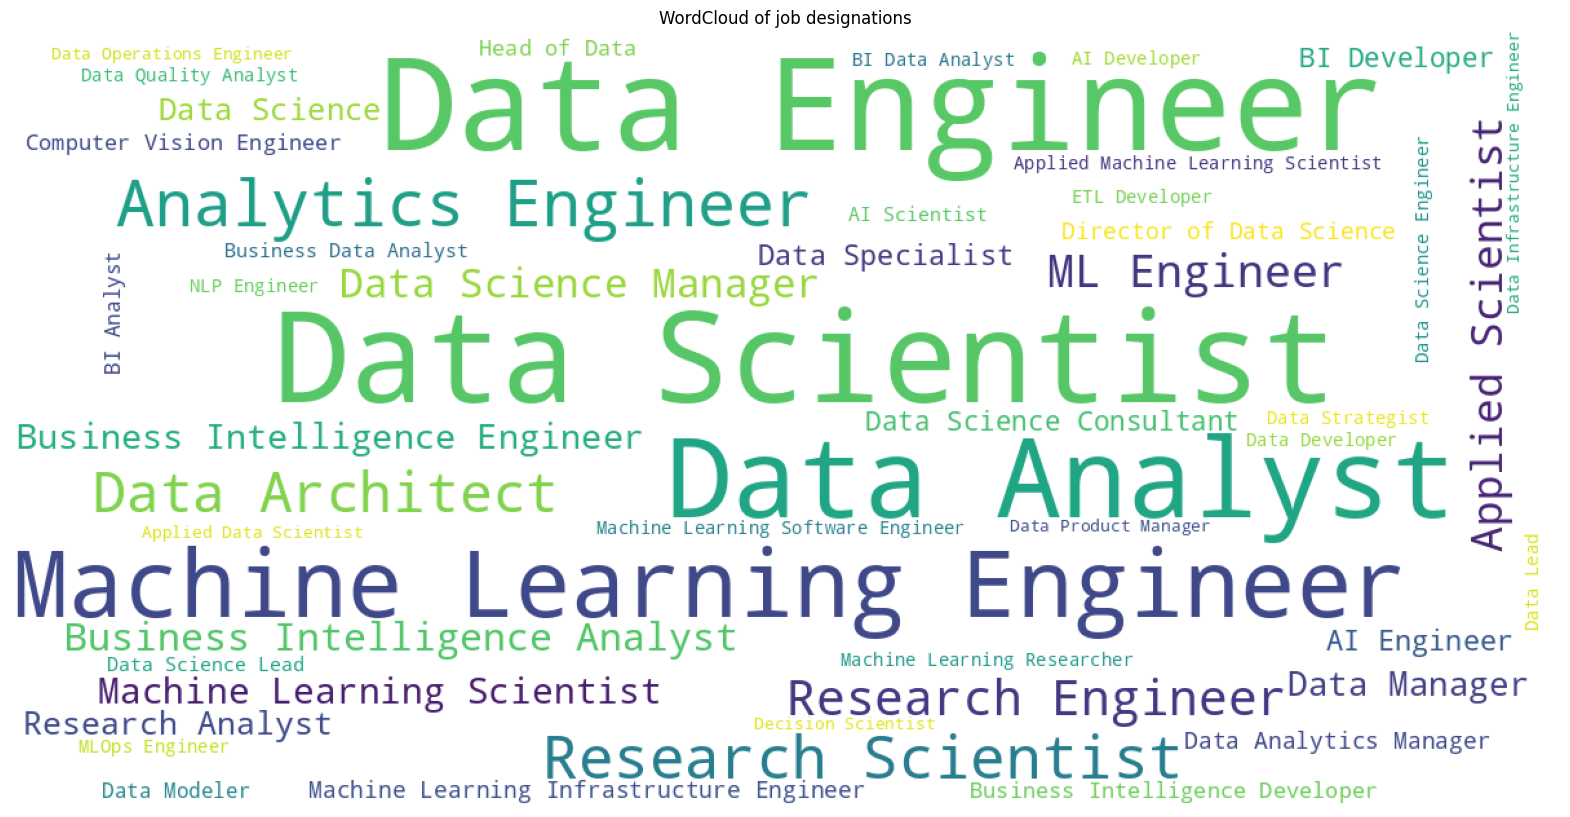

In [40]:
freq_df = Freq_df(df["job_title"].values.tolist())
data = dict(zip(freq_df["Term"].tolist(), freq_df["Frequency"].tolist()))
data = freq_df.set_index("Term").to_dict()["Frequency"]

Word_Cloud(data, "WordCloud of job designations")